# Support Vector Machines

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler

In [2]:
df_train = pd.read_csv('train_insurance_one_hot.csv')
df_test = pd.read_csv('test_insurance_one_hot.csv')
df_train['expensive'] = df_train['charges'] > 25000
df_test['expensive'] = df_test['charges'] > 25000
df_train = df_train.drop(columns=['charges'])
df_test = df_test.drop(columns=['charges'])
df_train = df_train.drop(columns=['chargeGroup'])
df_test = df_test.drop(columns=['chargeGroup'])

## a)

In [3]:

selected_features_first = ["age","bmi","smoker_yes"]
selected_features_second = ["age","bmi","sex_female","sex_male","smoker_no","smoker_yes","region_northeast","region_northwest","region_southeast","region_southwest"]
svm_model = SVC(kernel='linear', C=10)
# first svm 
x_train_filtered_first = df_train[selected_features_first]
y_train_filtered_first = df_train["expensive"]
x_test_filtered_first = df_test[selected_features_first]
y_test_filtered_first = df_test["expensive"]
svm_model.fit(x_train_filtered_first, y_train_filtered_first)
y_pred_first = svm_model.predict(x_test_filtered_first)
first_confusion = confusion_matrix(y_test_filtered_first,y_pred_first)


# second svm
x_train_filtered_second = df_train[selected_features_second]
y_train_filtered_second = df_train["expensive"]
x_test_filtered_second = df_test[selected_features_second]
y_test_filtered_second = df_test["expensive"]
svm_model.fit(x_train_filtered_second, y_train_filtered_second)
y_pred_second = svm_model.predict(x_test_filtered_second)
second_confusion = confusion_matrix(y_test_filtered_second,y_pred_second)

print('Confusion Matrix of the first SVM:')
print(first_confusion)
print('Confusion Matrix of the second SVM:')
print(second_confusion)

Confusion Matrix of the first SVM:
[[220   3]
 [  9  36]]
Confusion Matrix of the second SVM:
[[221   2]
 [  9  36]]


## b)

In [4]:
tn_first, fp_first, fn_first, tp_first =first_confusion.ravel().tolist()
tn_sec, fp_sec, fn_sec, tp_sec =second_confusion.ravel().tolist()
first_accuracy = (tn_first+tp_first)/(tn_first+ fp_first+ fn_first+ tp_first)
second_accuracy = (tn_sec+tp_sec)/(tn_sec+ fp_sec+ fn_sec+ tp_sec)
first_precision = tp_first /(tp_first+fp_first)
second_precision = tp_sec /(tp_sec+fp_sec)
print(f'Accuracy of the first SVM:{first_accuracy:.2f}')
print(f'Accuracy of the second SVM:{second_accuracy:.2f}')
print(f'Precision of the first SVM:{first_precision:.2f}')
print(f'Precision of the second SVM:{second_precision:.2f}')


Accuracy of the first SVM:0.96
Accuracy of the second SVM:0.96
Precision of the first SVM:0.92
Precision of the second SVM:0.95


## c)

In [5]:
import time
scaler = StandardScaler()
first_scaled_data_train= scaler.fit_transform(x_train_filtered_first)
first_scaled_data_test= scaler.transform(x_test_filtered_first)

second_scaled_data_train= scaler.fit_transform(x_train_filtered_second)
second_scaled_data_test= scaler.transform(x_test_filtered_second)
# first svm
start_time = time.time()
svm_model.fit(first_scaled_data_train, y_train_filtered_first)
y_pred_first_scaled = svm_model.predict(first_scaled_data_test)
first_confusion_scaled = confusion_matrix(y_test_filtered_first,y_pred_first_scaled)
end_time = time.time() 
elapsed_time = end_time - start_time
print(f"Elapsed time of first svm with scaled data: {elapsed_time:.4f} seconds")
#second svm
start_time = time.time()
svm_model.fit(second_scaled_data_train, y_train_filtered_second)
y_pred_second_scaled = svm_model.predict(second_scaled_data_test)
second_confusion_scaled = confusion_matrix(y_test_filtered_second,y_pred_second_scaled)
end_time = time.time() 
elapsed_time = end_time - start_time
print(f"Elapsed time of second svm with scaled data: {elapsed_time:.4f} seconds")

start_time = time.time()
svm_model.fit(x_train_filtered_first, y_train_filtered_first)
y_pred_first = svm_model.predict(x_test_filtered_first)
first_confusion = confusion_matrix(y_test_filtered_first,y_pred_first)
end_time = time.time() 
elapsed_time = end_time - start_time
print(f"Elapsed time of first svm without scaling data: {elapsed_time:.4f} seconds")

start_time = time.time()
svm_model.fit(x_train_filtered_second, y_train_filtered_second)
y_pred_second = svm_model.predict(x_test_filtered_second)
second_confusion = confusion_matrix(y_test_filtered_second,y_pred_second)
end_time = time.time() 
elapsed_time = end_time - start_time
print(f"Elapsed time of second svm without scaling data: {elapsed_time:.4f} seconds")

print('Confusion Matrix of the first SVM scaled:')
print(first_confusion_scaled)
print('Confusion Matrix of the second SVM scaled:')
print(second_confusion_scaled)


Elapsed time of first svm with scaled data: 0.0204 seconds
Elapsed time of second svm with scaled data: 0.0399 seconds
Elapsed time of first svm without scaling data: 0.3552 seconds
Elapsed time of second svm without scaling data: 0.4593 seconds
Confusion Matrix of the first SVM scaled:
[[220   3]
 [  9  36]]
Confusion Matrix of the second SVM scaled:
[[220   3]
 [  9  36]]


## d)

Accuracy values
['0.94']
['0.95']
['0.96']
['0.96']
['0.96']
['0.95']


'Highest accuracy : 0.96.'

Text(0, 0.5, 'Accuracy')

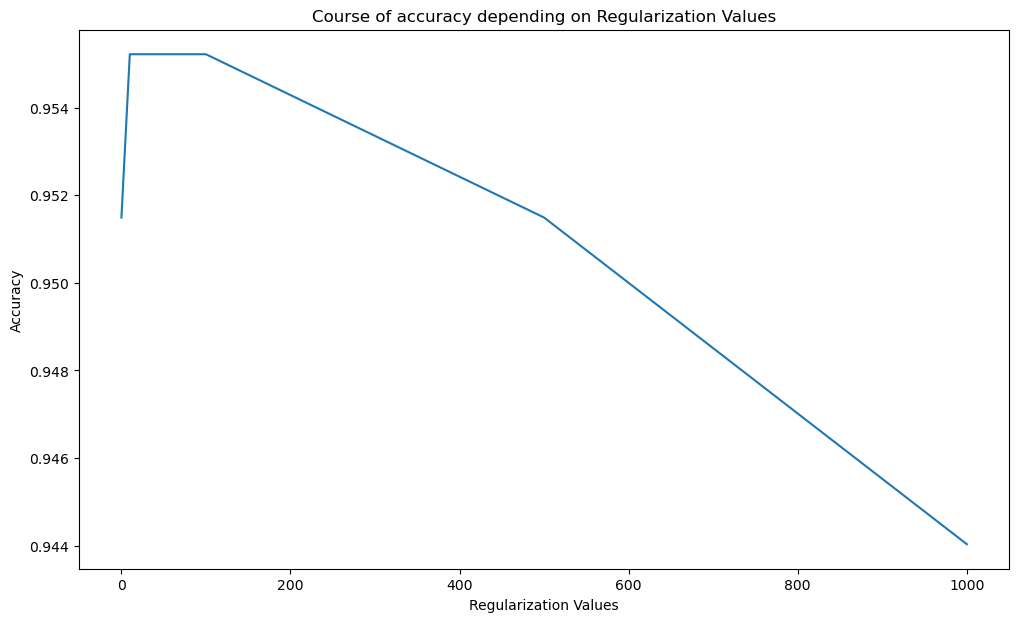

In [6]:
from sklearn import metrics
import matplotlib.pyplot as plt
regularization_values = [1000 , 500 , 100 , 50, 10 , 0.1]
accuracy_value =[]
for regularization_value in regularization_values:
    svm_model = SVC(kernel='linear', C=regularization_value)
    svm_model.fit(x_train_filtered_first, y_train_filtered_first)
    y_pred_first = svm_model.predict(x_test_filtered_first)
    accuracy_value.append(metrics.accuracy_score(y_test_filtered_first, y_pred_first))

print("Accuracy values")
for value in accuracy_value:
    print([f"{value:.2f}"])
display(f'Highest accuracy : {max(accuracy_value):.2f}.')
fig = plt.figure(figsize=(12,7))
plt.plot(regularization_values, accuracy_value)
plt.title("Course of accuracy depending on Regularization Values")
plt.xlabel("Regularization Values")
plt.ylabel("Accuracy")